1) Problem Statement
This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

2) Data Collection
Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
The data consists of 8 column and 1000 rows.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")


C:\Users\DYANJ\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("data/stud.csv")

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

3. Data Checks to perform

Check Missing values
Check Duplicates
Check data type
Check the number of unique values of each column
Check statistics of data set
Check various categories present in the different categorical column

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
#There are no missing values in the dataset.

In [7]:
df.duplicated().sum()

0

In [8]:
#thee are no duplicated values in the dataset.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
print(df.describe())

       math_score  reading_score  writing_score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [11]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
print("Categories in 'gender' column:")
print(df['gender'].unique())

print("Categories in 'race' column:")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' column:")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' column:")
print(df['lunch'].unique())

print("Categories in 'test preparation course' column:")
print(df['test_preparation_course'].unique())

Categories in 'gender' column:
['female' 'male']
Categories in 'race' column:
['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' column:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' column:
['standard' 'free/reduced']
Categories in 'test preparation course' column:
['none' 'completed']


In [13]:
numeric_columns = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_columns = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numeric columns: {}".format(len(numeric_columns), numeric_columns))
print("We have {} categorical columns: {}".format(len(categorical_columns), categorical_columns))

We have 3 numeric columns: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical columns: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [14]:
#Addind a new column 'total_score' & 'average_score' 
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
#Students who scored full marks in Math, Reading, and Writing
math_full = df[df['math_score'] == 100]['average_score'].count()
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()

print("Number of students who scored full marks in Math: {}".format(math_full))
print("Number of students who scored full marks in Reading: {}".format(reading_full))
print("Number of students who scored full marks in Writing: {}".format(writing_full))

Number of students who scored full marks in Math: 7
Number of students who scored full marks in Reading: 17
Number of students who scored full marks in Writing: 14


In [16]:
#Students who scored less than or equal to 20 in Math, Reading, and Writing
math_less_20 = df[df['math_score'] <= 20]['average_score'].count()
reading_less_20 = df[df['reading_score'] <= 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average_score'].count()

print("Number of students who scored less than or equal to 20 in Math: {}".format(math_less_20))
print("Number of students who scored less than or equal to 20 in Reading: {}".format(reading_less_20))
print("Number of students who scored less than or equal to 20 in Writing: {}".format(writing_less_20))

Number of students who scored less than or equal to 20 in Math: 4
Number of students who scored less than or equal to 20 in Reading: 1
Number of students who scored less than or equal to 20 in Writing: 3


Insights
Students have performed the worst in Math as compared to Reading and Writing. 
Students have performed the best in Reading as compared to Math and Writing.

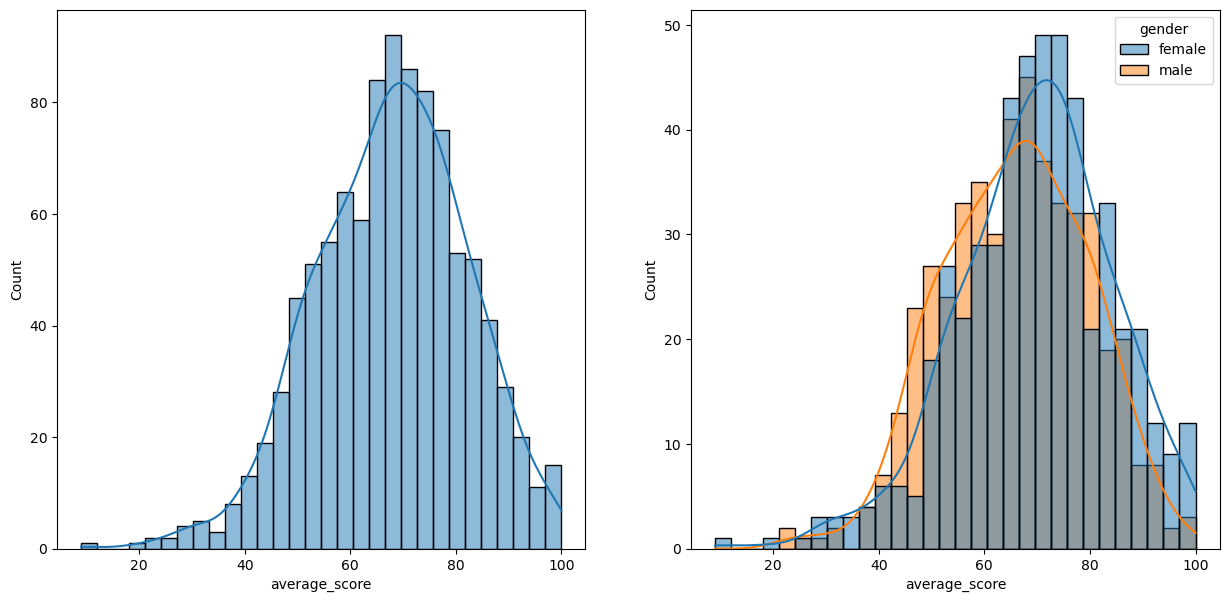

In [17]:
# Average score distribution across gender
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.histplot(df['average_score'], bins=30, kde=True)
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='average_score', hue='gender', bins=30, kde=True)
plt.show()

Female students have a higher average score than male students.

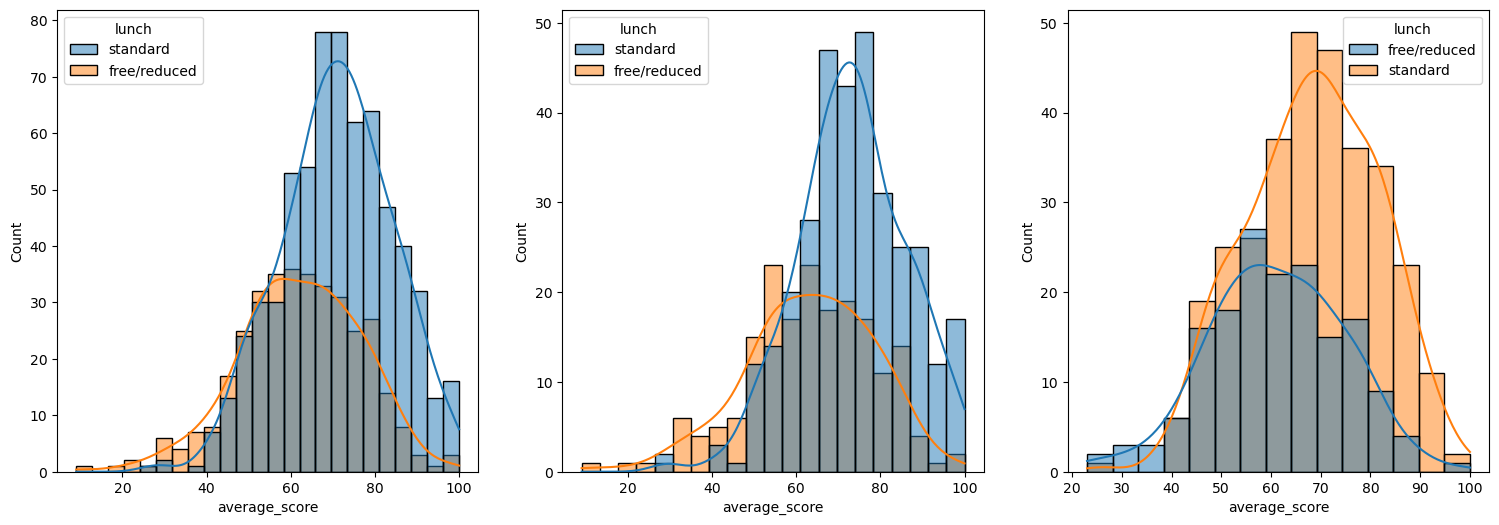

In [18]:
# Average score distribution across lunch types
plt.subplots(1,3,figsize=(25, 6))
plt.subplot(1, 4, 1)
sns.histplot(data=df, x='average_score', hue='lunch', kde=True)
plt.subplot(1, 4, 2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', hue='lunch', kde=True)
plt.subplot(1, 4, 3)  
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', hue='lunch', kde=True)
plt.show()

Standard lunch helps in better performance regardless of gender.

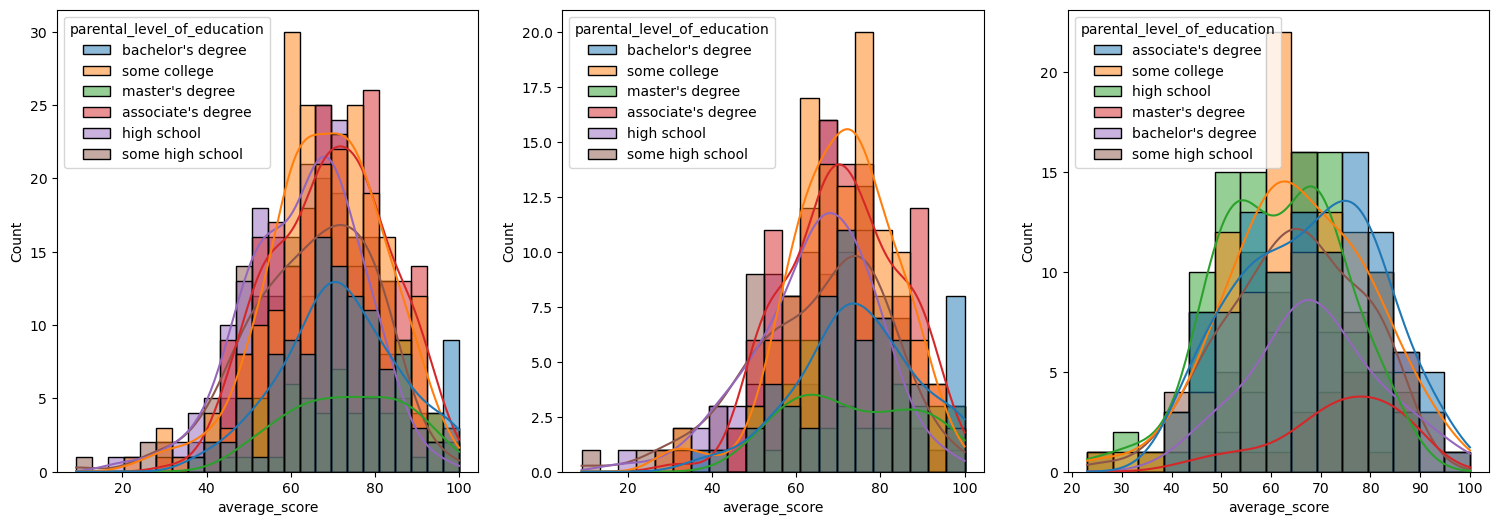

In [19]:
# Average score distribution across parental level of education
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1, 4, 1 )
sns.histplot(data=df, x='average_score', hue='parental_level_of_education', kde=True)
plt.subplot(1, 4, 2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', hue='parental_level_of_education', kde=True)
plt.subplot(1, 4, 3)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', hue='parental_level_of_education', kde=True)
plt.show()

In female, bachelors and master parental degree helps perform better in average score.
In male, associate and master parental degree helps perform better in average score.

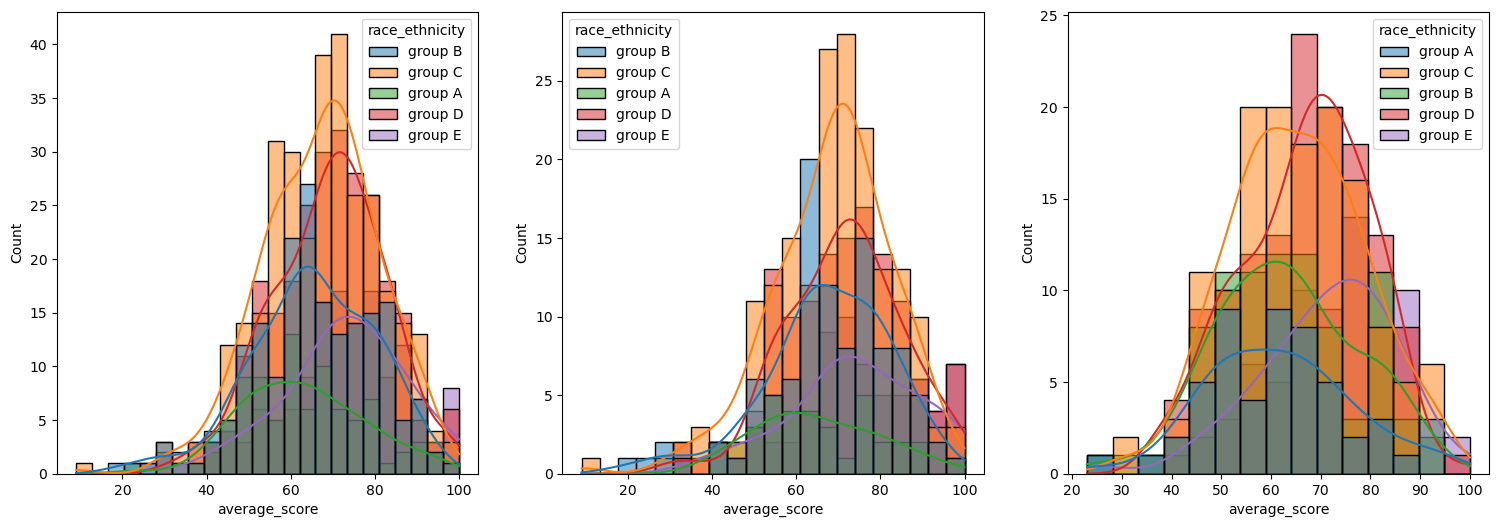

In [20]:
#average score distribution across race/ethnicity
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1, 4, 1)
sns.histplot(data=df, x='average_score', hue='race_ethnicity', kde=True)
plt.subplot(1, 4, 2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', hue='race_ethnicity', kde=True)
plt.subplot(1, 4, 3)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', hue='race_ethnicity', kde=True)
plt.show()

Group E has a good impact on avg score in general
Group A and group B tends to perform poorly

<function matplotlib.pyplot.show(close=None, block=None)>

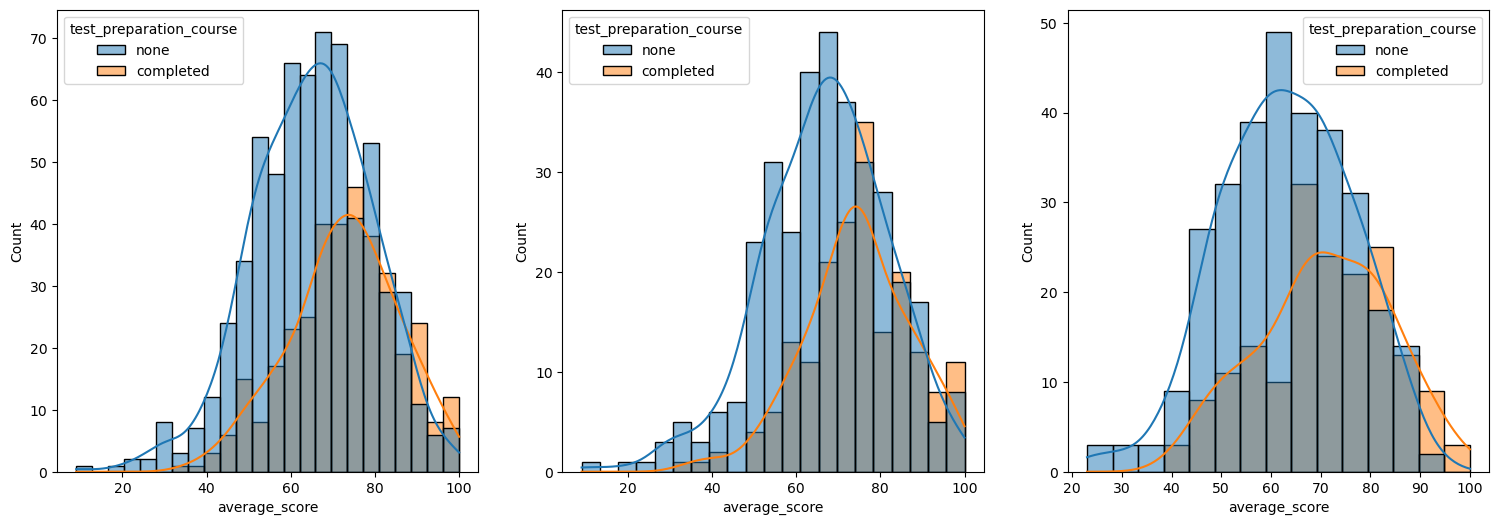

In [21]:
#average score distribution across test preparation course
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1, 4, 1)
sns.histplot(data=df, x='average_score', hue='test_preparation_course', kde=True)
plt.subplot(1, 4, 2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', hue='test_preparation_course', kde=True)
plt.subplot(1, 4, 3)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', hue='test_preparation_course', kde=True)
plt.show

Completed test preparation course tends to have avg score between 70-80 regardless of gender
While none test preparation course tends to have avg score between 60-70

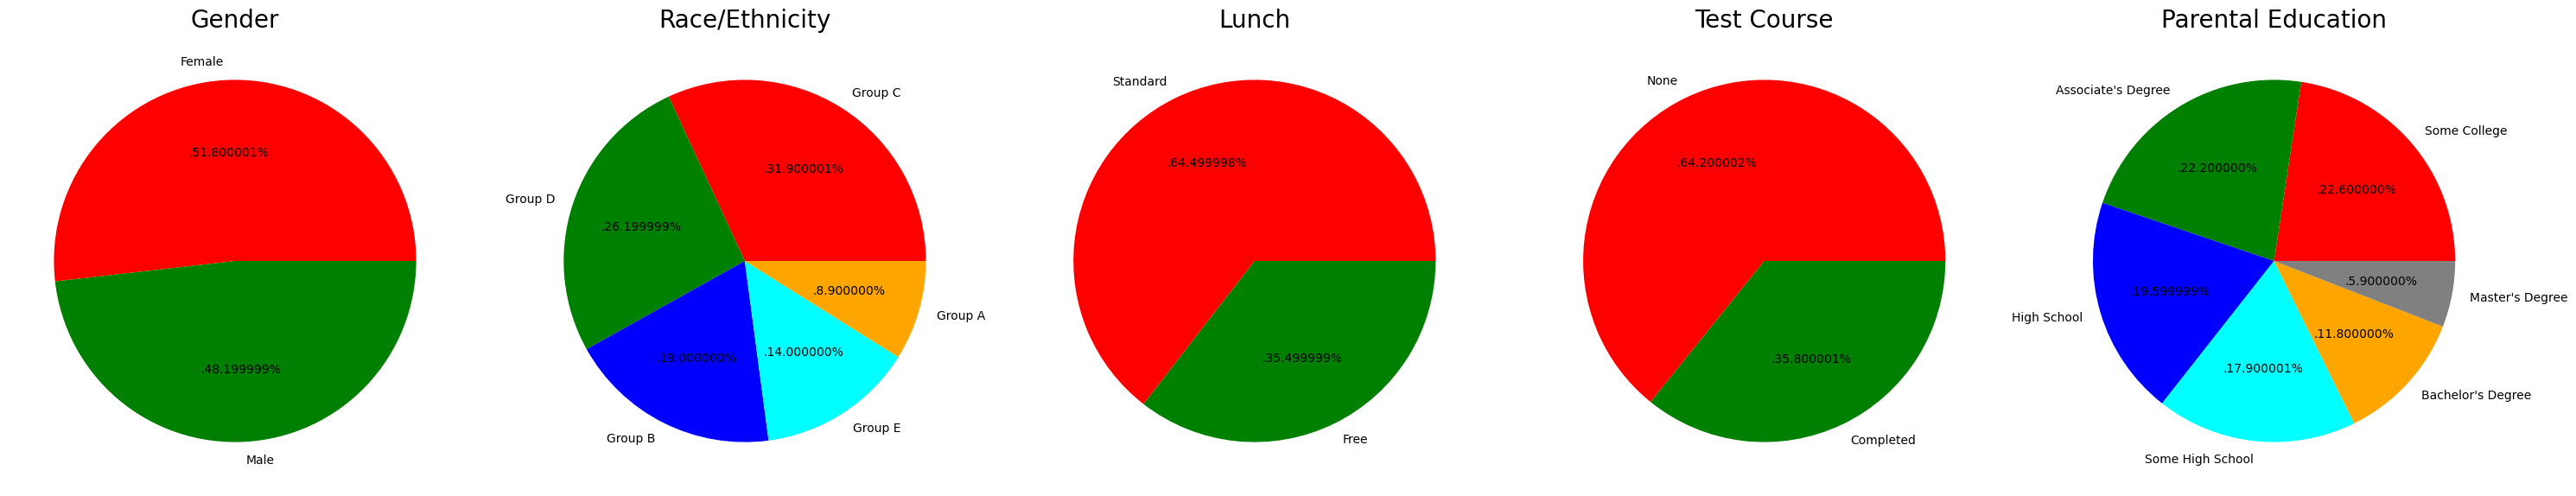

In [25]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#Insights
Number of Male and Female students is almost equal
Number students are greatest in Group C
Number of students who have standard lunch are greater
Number of students who have not enrolled in any test preparation course is greater
Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

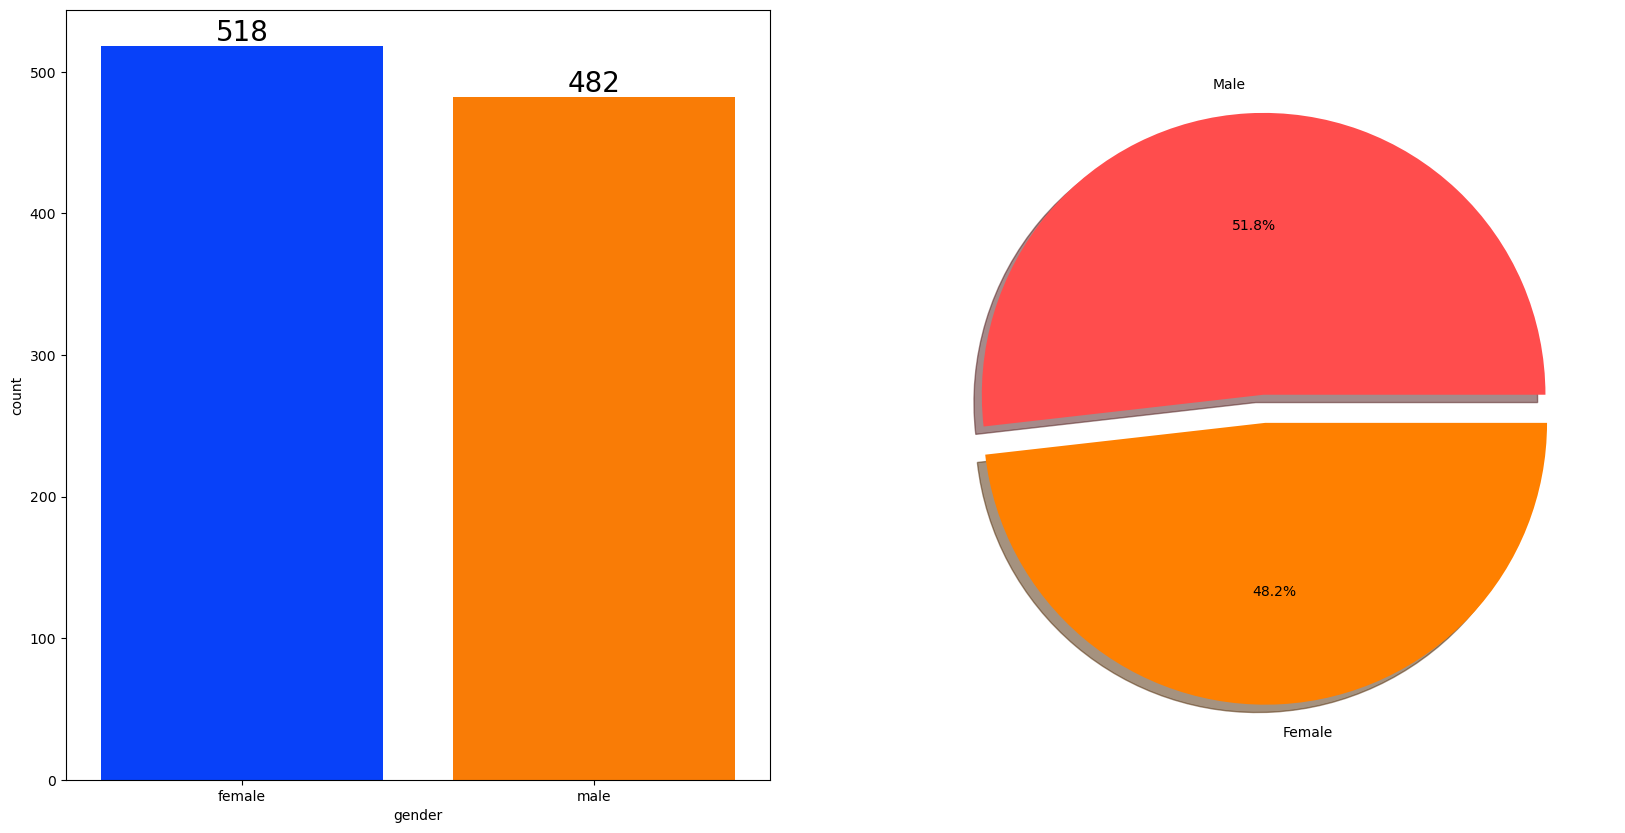

In [26]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

In [34]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


In [ ]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average_score'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average_score'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()


KeyError: 'average'

<Figure size 1000x800 with 0 Axes>